https://www.nature.com/articles/s41586-021-03569-1

In [7]:
%load_ext autoreload
%autoreload 2

import sys, os

# Add parent directory to Python path
sys.path.append(os.path.abspath(".."))  

In [7]:
from scrna_pipeline.utils import per_sample_export

In [3]:


report = per_sample_export.export_per_sample_h5ads(
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/GSE171524_RAW_merged.h5ad",
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw",
    sample_key="sample",      # <-- your obs column

    filename_suffix="raw",
)
print(report.n_cells_per_sample)


sample_id
GSM5226574_C51ctr         6099
GSM5226575_C52ctr         4513
GSM5226576_C53ctr         7120
GSM5226577_C54ctr         4382
GSM5226578_C55ctr         5685
GSM5226579_C56ctr         4090
GSM5226580_C57ctr         4789
GSM5226581_L01cov         3060
GSM5226582_L03cov         5060
GSM5226583_L04cov         3630
GSM5226584_L04covaddon    4574
GSM5226585_L05cov         3052
GSM5226586_L06cov         7582
GSM5226587_L07cov         5074
GSM5226588_L08cov         4149
GSM5226589_L09cov         3605
GSM5226590_L10cov         1550
GSM5226591_L11cov         3296
GSM5226592_L12cov         3876
GSM5226593_L13cov         4862
GSM5226594_L15cov         4056
GSM5226595_L16cov         1822
GSM5226596_L17cov         4651
GSM5226597_L18cov         2816
GSM5226598_L19cov         2509
GSM5226599_L21cov         3425
GSM5226600_L22cov         6987
Name: count, dtype: int64


In [11]:
BROAD_MARKERS = {
    "Epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "T_cell": ["CD3D", "CD3E", "CD2", "CD8A", "CD4"],
    "B_cell": ["MS4A1", "CD79A", "CD79B"],
    "Myeloid": ["LYZ", "CD68", "CD14", "TYROBP", "LST1", "CSF1R", "FCGR3A"],
    "Endothelial": ["PECAM1", "VWF", "KDR"],
    "Fibroblast": ["COL1A1", "COL1A2", "DCN"],
    "Mast": ["TPSAB1", "TPSB2", "CPA3"],
}

In [ ]:
import scanpy as sc

from scrna_pipeline.core.pipeline import StepContext, run_steps
from scrna_pipeline.pipelines.standard_per_sample import standard_per_sample_pipeline

# 1) Load one raw per-sample h5ad
adata = sc.read_h5ad("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226595_L16cov.raw.h5ad")



# 2) Build the step list (strict workflow)
steps = standard_per_sample_pipeline(
    batch_key="batch",          # must exist in adata.obs
    marker_dict=BROAD_MARKERS,  # your dict[str, list[str]]
    # optional: override defaults if you want
    # n_top_genes=2000, n_pcs=50, n_neighbors=15, resolution=0.6, ...
)

# 3) Execute steps
ctx = StepContext(verbose=True, strict=True)
adata = run_steps(adata, steps, ctx=ctx)

adata


[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226595_L16cov kept 1374/1822 | max_genes=3032, max_counts=6627, max_mito=7.37
[QC filter] removed 448 cells; remaining 1374
Running Scrublet for doublet detection...
Removed 4 predicted doublets
After doublet removal: (1370, 19457)
[steps] 01/03 preprocess_to_pca: done (0.75s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (1.11s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.08s)


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


AnnData object with n_obs × n_vars = 1370 × 19457
    obs: 'sample', 'file', 'batch', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'broad_Epithelial_score', 'broad_T_cell_score', 'broad_B_cell_score', 'broad_Myeloid_score', 'broad_Endothelial_score', 'broad_Fibroblast_score', 'broad_Mast_score', 'broad_celltype'
    var: 'n_cells', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'scrna_pipeline', 'scrublet', 'log1p', 'hvg', 'pc

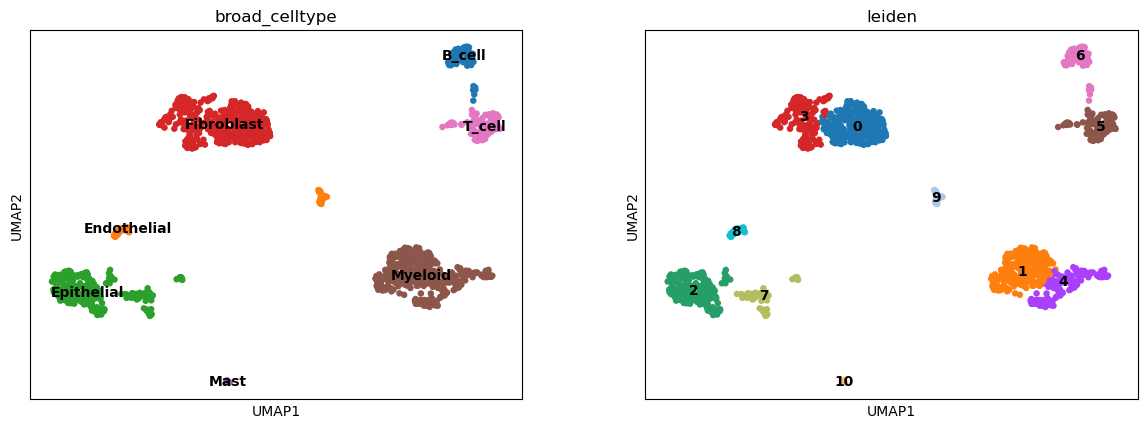

In [14]:
sc.pl.umap(adata, color=["broad_celltype", "leiden"], legend_loc="on data")


# Full Batch

In [12]:
import scanpy as sc


adata1 = sc.read_h5ad("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226595_L16cov.raw.h5ad")
adata2 = sc.read_h5ad("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226586_L06cov.raw.h5ad")

adatas_dict = {'GSM5226595_L16cov': adata1, 'GSM5226586_L06cov': adata2}

In [13]:
from anndata import AnnData

def show_umap_summary(name: str, adata: AnnData) -> None:
    print(f"\n### Sample: {name}")
    sc.pl.umap(
        adata,
        color=["broad_celltype", "leiden"],
        legend_loc="on data",
        show=True,
    )


=== [GSM5226595_L16cov] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226595_L16cov kept 1374/1822 | max_genes=3032, max_counts=6627, max_mito=7.37
[QC filter] removed 448 cells; remaining 1374
Running Scrublet for doublet detection...
Removed 4 predicted doublets
After doublet removal: (1370, 19457)
[steps] 01/03 preprocess_to_pca: done (1.06s)
[steps] 02/03 cluster_and_embed: start


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/clustering.py:108: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


[steps] 02/03 cluster_and_embed: done (4.29s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.08s)

### Sample: GSM5226595_L16cov


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


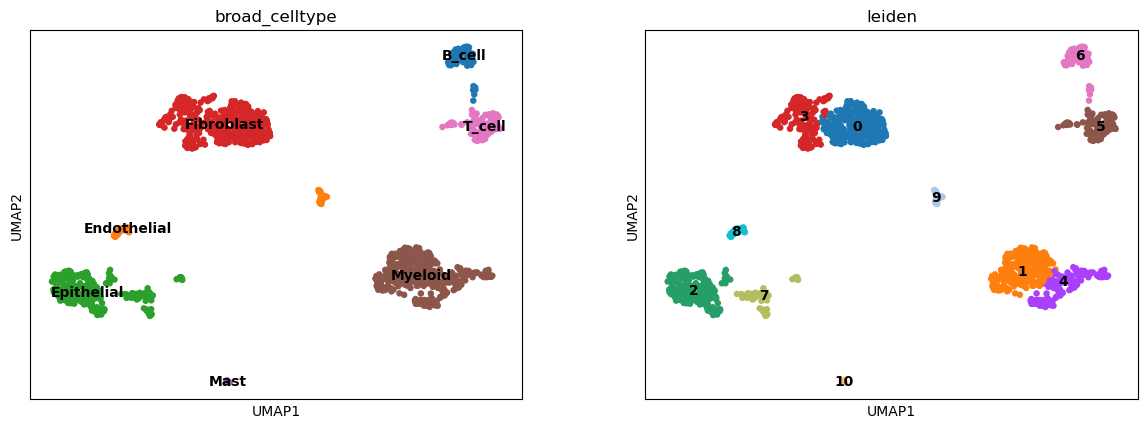

=== [GSM5226595_L16cov] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226595_L16cov.processed.h5ad (13.6 MB) ===

=== [GSM5226586_L06cov] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226586_L06cov kept 5832/7582 | max_genes=3903, max_counts=9273, max_mito=5.56
[QC filter] removed 1750 cells; remaining 5832
Running Scrublet for doublet detection...
Removed 49 predicted doublets
After doublet removal: (5783, 23592)
[steps] 01/03 preprocess_to_pca: done (19.08s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (8.70s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.28s)

### Sample: GSM5226586_L06cov


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


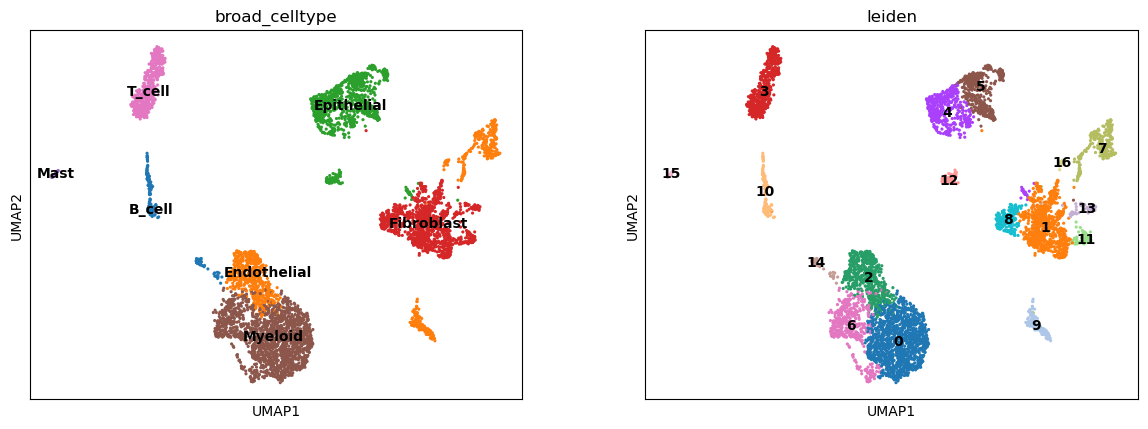

=== [GSM5226586_L06cov] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226586_L06cov.processed.h5ad (54.7 MB) ===


{'GSM5226595_L16cov': PosixPath('/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226595_L16cov.processed.h5ad'),
 'GSM5226586_L06cov': PosixPath('/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226586_L06cov.processed.h5ad')}

In [14]:
from pathlib import Path

from scrna_pipeline.core.batch_runner import (
    BatchRunConfig,
    run_pipeline_on_batch,
    run_pipeline_on_h5ad_folder,
    constant_kwargs_factory,
)
from scrna_pipeline.pipelines.standard_per_sample import standard_per_sample_pipeline

# 1) Config for saving/execution
cfg = BatchRunConfig(
    out_dir=Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed"),
    strip_graph=True,      # remove neighbors graph before saving
    keep_umap=True,        # keep X_umap
    keep_pca=True,         # keep X_pca
    compression="gzip",
    verbose=True,
    strict=True,
)

# 2) Same pipeline kwargs for every sample
kwargs_factory = constant_kwargs_factory({
    "batch_key": "batch",           # must exist in each adata.obs
    "marker_dict": BROAD_MARKERS,   # dict[str, list[str]]
})

# 3) Run for all samples and save <name>.processed.h5ad
saved = run_pipeline_on_batch(
    adatas_dict,  # {"sample1": adata1, "sample2": adata2, ...}
    pipeline=standard_per_sample_pipeline,
    kwargs_factory=kwargs_factory,
    config=cfg,
    on_sample_done=show_umap_summary,

)

# saved is a dict: {sample_name: Path_to_saved_h5ad}
saved



=== [GSM5226586_L06cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw_some/GSM5226586_L06cov.raw.h5ad ===

=== [GSM5226586_L06cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226586_L06cov kept 5832/7582 | max_genes=3903, max_counts=9273, max_mito=5.56
[QC filter] removed 1750 cells; remaining 5832
Running Scrublet for doublet detection...
Removed 49 predicted doublets
After doublet removal: (5783, 23592)
[steps] 01/03 preprocess_to_pca: done (10.52s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (5.87s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.21s)

### Sample: GSM5226586_L06cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


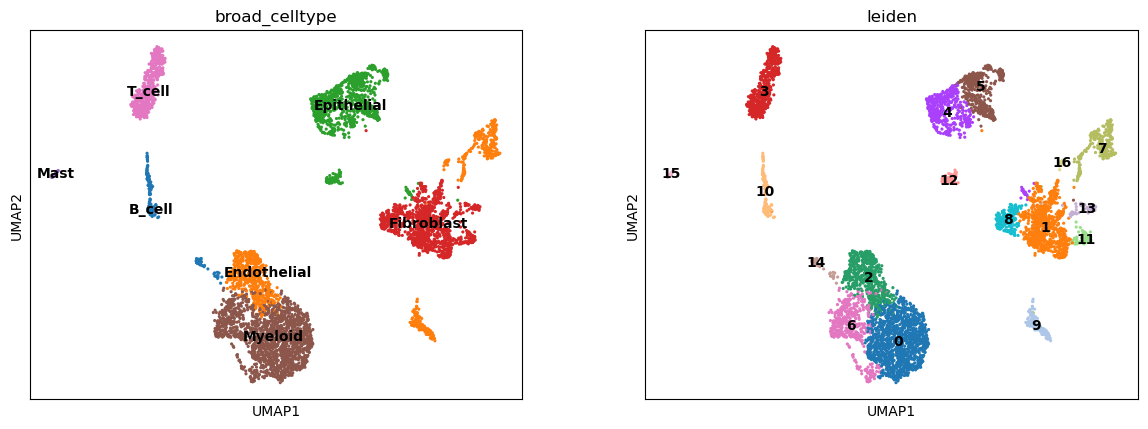

=== [GSM5226586_L06cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed/GSM5226586_L06cov.raw.processed.h5ad (54.7 MB) ===
=== [GSM5226586_L06cov.raw] deleted input: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw_some/GSM5226586_L06cov.raw.h5ad ===

=== [GSM5226595_L16cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw_some/GSM5226595_L16cov.raw.h5ad ===

=== [GSM5226595_L16cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226595_L16cov kept 1374/1822 | max_genes=3032, max_counts=6627, max_mito=7.37
[QC filter] removed 448 cells; remaining 1374
Running Scrublet for doublet detection...
Removed 4 predicted doublets
After doublet removal: (1370, 19457)
[steps] 01/03 preprocess_to_pca: done (0.66s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (1.10s)
[steps] 03/03

/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


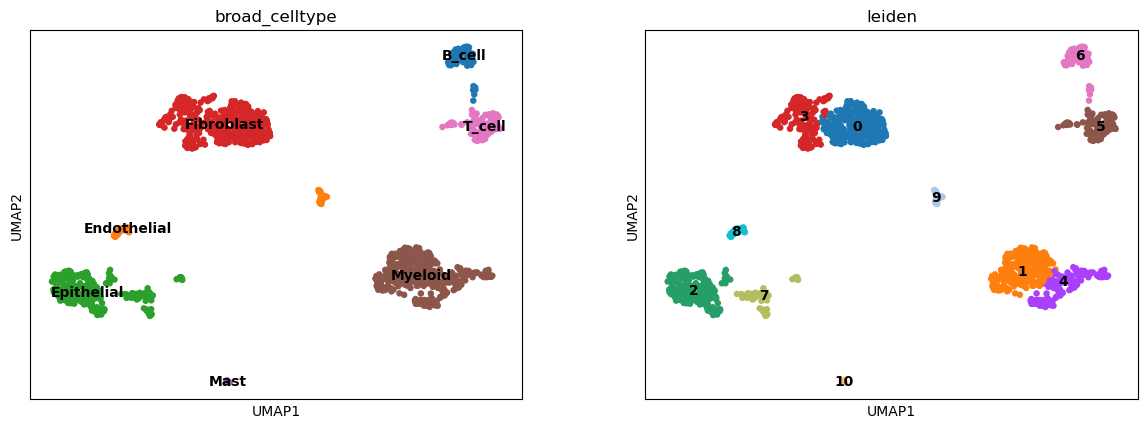

=== [GSM5226595_L16cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed/GSM5226595_L16cov.raw.processed.h5ad (13.6 MB) ===
=== [GSM5226595_L16cov.raw] deleted input: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw_some/GSM5226595_L16cov.raw.h5ad ===


In [15]:
cfg = BatchRunConfig(
    out_dir=Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed"),
    strip_graph=True,      # remove neighbors graph before saving
    keep_umap=True,        # keep X_umap
    keep_pca=True,         # keep X_pca
    compression="gzip",
    verbose=True,
    strict=True,
)

saved = run_pipeline_on_h5ad_folder(
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw_some",
    pipeline=standard_per_sample_pipeline,
    kwargs_factory=kwargs_factory,
    config=cfg,
    delete_inputs=True,   # deletes raw only after successful save
    on_sample_done=show_umap_summary,  # or None
)